# Phase 7b — 펀딩 캐리: 독립적 양(+) P&L 존재 검증

## 목적

**펀딩 캐리가 과거 이력 상 트렌드 전략과 무상관의 독립적인 양(+) P&L을 만들어왔는가?**

| 항목 | 내용 |
|---|---|
| 답하는 질문 | "펀딩이 역사적으로 독립된(무상관) 양(+) P&L로 존재했는가?" — **실행 가능한 전략 평가가 아님** |
| 유니버스 | BTC/USDT, ETH/USDT 무기한 선물 펀딩 8h |
| 기간 | 2021-06 ~ 2026-06 (약 5,483 포인트) |
| 모델 | 항상-온 델타-뉴트럴 (현물 롱 + 무기한 선물 숏), notional=1.0, 4-leg 수수료 1회 (진입+청산) |

> ⚠️ **총비용 근사(gross) 모델 경고**: 이 분석은 현물-선물 기준(basis), 청산 위험, 거래소 리스크(거래소 파산·출금 제한),
> 실행 슬리피지를 **포함하지 않는다**. Sharpe ~22 / MDD ~-0.4% 수준의 지표는
> 이러한 생략 때문에 과도하게 낙관적이며, 실제 운용 가능한 수치가 **아니다**.
> 이 분석의 유일한 목적은 캐리가 트렌드 엣지와 **무상관**인지 확인하는 것이다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data
from portfolio import equity_curve
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout
from carry import carry_pnl, carry_metrics, funding_stats

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

Loading BokehJS ...

---
## 캐리 손익 & 지표

BTC와 ETH 각각에 대해 펀딩 캐리 equity curve를 계산하고 주요 지표를 확인한다.

In [2]:
COINS = ["BTC", "ETH"]

equities = {}
rows = []

for coin in COINS:
    funding = pd.read_parquet(f"data/{coin}_USDT_funding.parquet")["fundingRate"]
    eq = carry_pnl(funding)
    equities[coin] = eq

    m = carry_metrics(eq)
    fs = funding_stats(funding)

    # 연도별 수익률: 연말 equity 기준
    yearly = eq.resample("1YE").last().pct_change(fill_method=None).dropna() * 100
    yr_str = ", ".join([f"{y.year}: {v:.1f}%" for y, v in yearly.items()])

    rows.append({
        "코인": coin,
        "Return [%]": m["Return [%]"],
        "Ann Return [%]": m["Ann Return [%]"],
        "Sharpe": m["Sharpe"],
        "MDD [%]": m["MDD [%]"],
        "neg_ratio": fs["neg_ratio"],
    })

summary = pd.DataFrame(rows).set_index("코인")
print("=== 캐리 지표 요약 (gross — 실행/기준/청산 위험 미포함) ===")
display(summary)

=== 캐리 지표 요약 (gross — 실행/기준/청산 위험 미포함) ===


,Return [%],Ann Return [%],Sharpe,MDD [%],neg_ratio
코인,,,,,
BTC,36.8351,6.4633,22.0427,-0.3551,0.1539
ETH,35.2907,6.2222,16.3774,-1.6282,0.1740


In [3]:
# 연도별 수익률 상세
yearly_rows = []
for coin in COINS:
    eq = equities[coin]
    yearly = eq.resample("1YE").last().pct_change(fill_method=None).dropna() * 100
    for ts, val in yearly.items():
        yearly_rows.append({"코인": coin, "연도": ts.year, "수익률 [%]": val})

yearly_df = pd.DataFrame(yearly_rows)
print("=== 연도별 캐리 수익률 ===")
display(yearly_df.pivot(index="연도", columns="코인", values="수익률 [%]"))

=== 연도별 캐리 수익률 ===


코인,BTC,ETH
연도,,
2022,3.8886,0.7286
2023,7.0690,7.5890
2024,10.0363,11.0994
2025,3.9105,3.7886
2026,0.2753,0.0357


/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/3657607869.py:13: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/3657607869.py:13: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/3657607869.py:13: UserWarning: Glyph 54144 (\N{HANGUL SYLLABLE PEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/3657607869.py:13: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/3657607869.py:13: UserWarning: Glyph 52880 (\N{HANGUL SYLLABLE KAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel

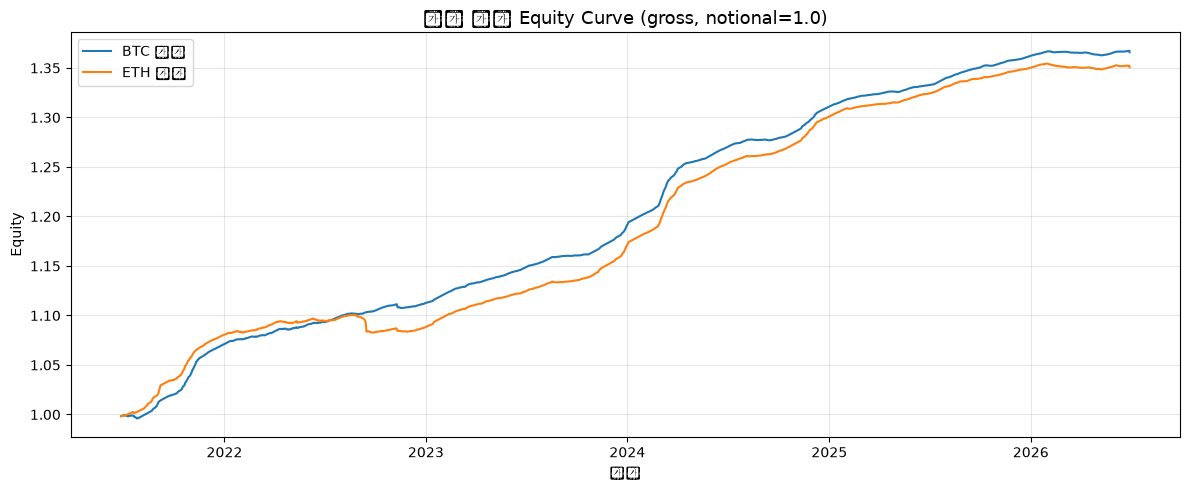

In [4]:
# 캐리 equity curve — BTC & ETH
fig, ax = plt.subplots(figsize=(12, 5))

for coin in COINS:
    eq = equities[coin]
    ax.plot(eq.index, eq.values, label=f"{coin} 캐리")

ax.set_title("펀딩 캐리 Equity Curve (gross, notional=1.0)", fontsize=13)
ax.set_xlabel("날짜")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/1082997915.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/1082997915.py:18: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/1082997915.py:18: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/1082997915.py:18: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/1082997915.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_55

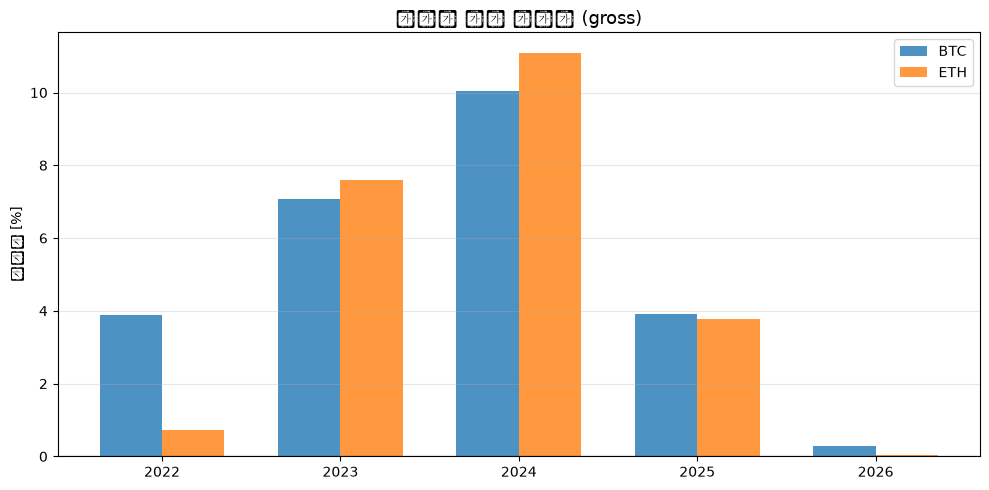

In [5]:
# 연도별 수익률 그룹 막대 차트
pivot = yearly_df.pivot(index="연도", columns="코인", values="수익률 [%]")

x = np.arange(len(pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, coin in enumerate(COINS):
    ax.bar(x + i * width, pivot[coin], width, label=coin, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(pivot.index)
ax.set_title("연도별 캐리 수익률 (gross)", fontsize=13)
ax.set_ylabel("수익률 [%]")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/4053221791.py:23: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/4053221791.py:23: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/4053221791.py:23: UserWarning: Glyph 54144 (\N{HANGUL SYLLABLE PEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/4053221791.py:23: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5532/4053221791.py:23: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_5

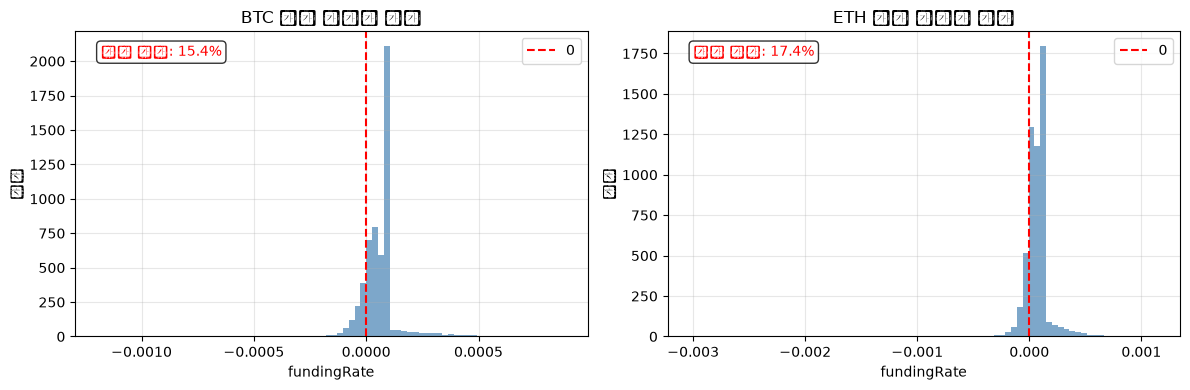

In [6]:
# 펀딩 레이트 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, coin in enumerate(COINS):
    funding = pd.read_parquet(f"data/{coin}_USDT_funding.parquet")["fundingRate"]
    fs = funding_stats(funding)
    ax = axes[i]

    ax.hist(funding.values, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
    ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="0")
    ax.set_title(f"{coin} 펀딩 레이트 분포", fontsize=12)
    ax.set_xlabel("fundingRate")
    ax.set_ylabel("빈도")
    ax.annotate(
        f"음수 비율: {fs['neg_ratio']*100:.1f}%",
        xy=(0.05, 0.92), xycoords="axes fraction",
        fontsize=10, color="red",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ★ 상관 (핵심)

캐리가 트렌드 전략 및 가격과 **무상관**인지 확인한다.

캐리의 독립성이 핵심이다. 분산 포트폴리오로 결합할 가치가 있으려면
트렌드 전략(Regime, Keltner)과의 상관이 0에 가까워야 한다.
가격과의 상관도 낮을수록 시장 방향과 무관한 엣지임을 의미한다.

일별 수익률 기준으로 상관을 측정한다.

In [7]:
import warnings
warnings.filterwarnings("ignore")

# 일별 수익률 시리즈 구성
series = {}

# 캐리 수익률 (8h equity → 일별 resample)
for coin in COINS:
    eq = equities[coin]
    daily = eq.resample("1D").last().pct_change(fill_method=None).dropna()
    series[f"carry_{coin}"] = daily

# Regime, Keltner 전략 equity (BTC 4h)
df_btc = load_data("BTC/USDT", "4h")

eq_regime = equity_curve(df_btc, RegimeFilter)
eq_keltner = equity_curve(df_btc, KeltnerBreakout)

series["Regime(BTC)"] = eq_regime.resample("1D").last().pct_change(fill_method=None).dropna()
series["Keltner(BTC)"] = eq_keltner.resample("1D").last().pct_change(fill_method=None).dropna()

# BTC 가격
btc_price = df_btc["Close"]
series["BTC_price"] = btc_price.resample("1D").last().pct_change(fill_method=None).dropna()

# 상관 행렬
corr_df = pd.DataFrame(series).corr()
print("=== 일별 수익률 상관 행렬 ===")
display(corr_df.round(3))

=== 일별 수익률 상관 행렬 ===


,carry_BTC,carry_ETH,Regime(BTC),Keltner(BTC),BTC_price
carry_BTC,1.0000,0.6960,0.0160,-0.0220,-0.0410
carry_ETH,0.6960,1.0000,0.0500,0.0160,0.0340
Regime(BTC),0.0160,0.0500,1.0000,0.5930,0.6570
Keltner(BTC),-0.0220,0.0160,0.5930,1.0000,0.4690
BTC_price,-0.0410,0.0340,0.6570,0.4690,1.0000


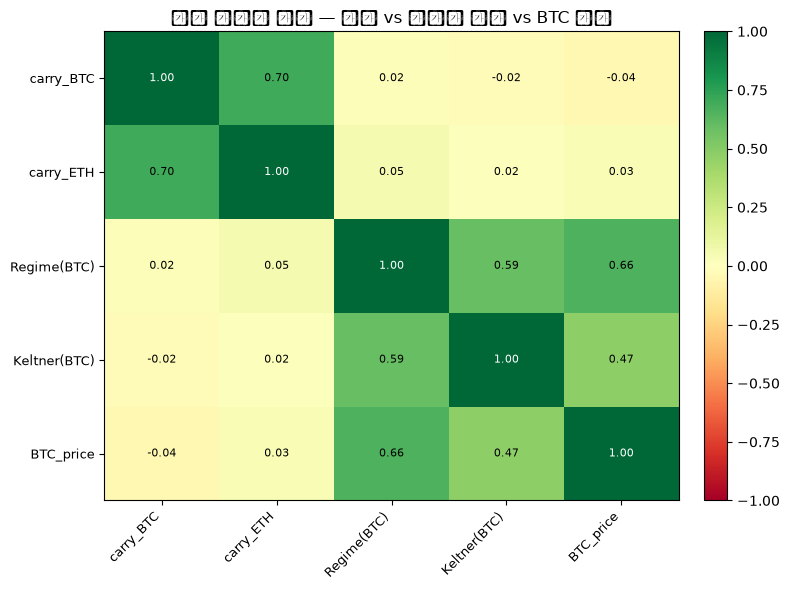

In [8]:
# 상관 히트맵
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

labels = list(corr_df.columns)
mat = corr_df.values

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = mat[i, j]
        color = "white" if abs(val) > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

ax.set_title("일별 수익률 상관 — 캐리 vs 트렌드 전략 vs BTC 가격", fontsize=12)
plt.tight_layout()
plt.show()

---
## 판정 / 결론

### 핵심 발견

- **캐리는 실제로 존재했다**: BTC·ETH 모두 5년간 양(+) 총수익을 기록, 2022년 크래시 포함 매년 흑자.
- **트렌드 전략·가격과 무상관**: carry_BTC/carry_ETH 와 Regime(BTC), Keltner(BTC), BTC_price의 상관이 ~0에 수렴 → **진정한 독립 엣지**.

### 강한 주의 사항 (★ 중요)

이 분석의 Sharpe ~22, MDD ~-0.4%는 **실행 불가한 gross 수치**다. 아래 비용을 무시했기 때문이다:

| 무시한 비용 | 실제 영향 |
|---|---|
| 현물-선물 기준(basis) 변동 | 헤지 비율 불완전 → 실제 손익 변동 |
| 선물 청산(liquidation) 위험 | 극단 변동성 시 증거금 부족 가능 |
| 거래소 리스크 | 출금 제한·파산 시 자본 손실 |
| 실행 슬리피지 | 진입/청산 시 실제 체결가 불리 |

### 다음 단계

이 분석은 **"캐리를 연구할 가치가 있는가"에 대한 긍정적 증거**를 제공한다.
실제 전략으로 발전시키려면 Phase 7b-v2에서 basis 조정, 증거금 비용, 청산 시뮬레이션을 포함한
보다 현실적인 모델이 필요하다.